In [19]:
import argparse
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R, Slerp

import ipywidgets as widgets
from IPython.display import display

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['savefig.dpi'] = 200
plt.rc('legend',fontsize=6)

%matplotlib widget

In [4]:
def normalize_time(t):
    t = np.array(t)
    return t - t[0]


def unwrap_euler(euler_deg):
    return np.degrees(np.unwrap(np.radians(euler_deg), axis=0))

In [27]:
FILENAME = "TUG3"
df_opti = pd.read_csv(f"../data/opti_{FILENAME}.csv")
df_app = pd.read_csv(f"../data/app_{FILENAME}.csv")
df_app = df_app.loc[df_app["source"] == "airpods"]

In [ ]:
OPTI_TIME_OFFSET = -100

time_opti = df_opti["timestampEpoch"].values - OPTI_TIME_OFFSET
time_app = df_app["timestampEpoch"].values

rot_opti = R.from_quat(df_opti[["quatX", "quatY", "quatZ", "quatW"]].values)
rot_app = R.from_euler(
    "xyz", df_app[["angle_pitch", "angle_roll", "angle_yaw"]].values
)

# Mask to get overlapping time only
time_start = max(time_opti[0], time_app[0])
time_end = min(time_opti[-1], time_app[-1])
mask_opti = (time_opti >= time_start) & (time_opti <= time_end)
mask_app = (time_app >= time_start) & (time_app <= time_end)

time_opti = time_opti[mask_opti]
rot_opti = rot_opti[mask_opti]
time_app = time_app[mask_app]
rot_app = rot_app[mask_app]

euler_opti = unwrap_euler(rot_opti.as_euler("zxy", degrees=True))
euler_app = unwrap_euler(rot_app.as_euler("xyz", degrees=True))

pitch_a, roll_a, yaw_a = euler_app.T
pitch_o, roll_o, yaw_o = euler_opti.T
roll_o *= -1
pitch_o *= -1


In [43]:
plt.close()

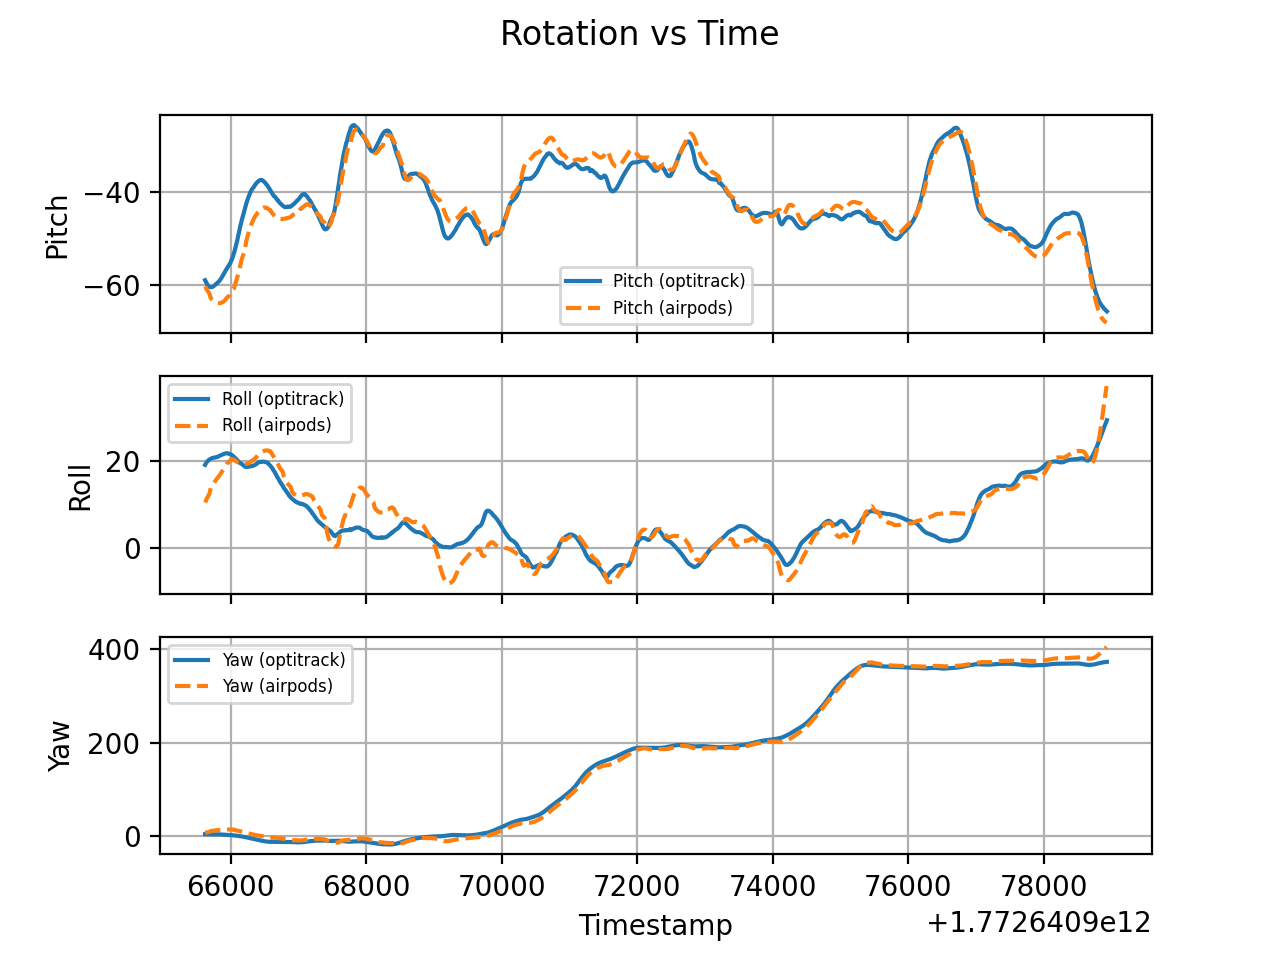

In [46]:
fig, axes = plt.subplots(3, 1, sharex=True)

axes[0].plot(time_opti, pitch_o, label="Pitch (optitrack)")
# axes[0].plot(time_opti, pitch_oc, label="Pitch (optitrackC)")
axes[0].plot(time_app, pitch_a, linestyle="--", label="Pitch (airpods)")
axes[0].set_ylabel("Pitch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_opti, roll_o, label="Roll (optitrack)")
# axes[1].plot(time_opti, roll_oc, label="Roll (optitrackC)")
axes[1].plot(time_app, roll_a, linestyle="--", label="Roll (airpods)")
axes[1].set_ylabel("Roll")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time_opti, yaw_o, label="Yaw (optitrack)")
# axes[2].plot(time_opti, yaw_oc, label="Yaw (optitrackC)")
axes[2].plot(time_app, yaw_a, linestyle="--", label="Yaw (airpods)")
axes[2].set_ylabel("Yaw")
axes[2].set_xlabel("Timestamp")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Rotation vs Time")
plt.show()


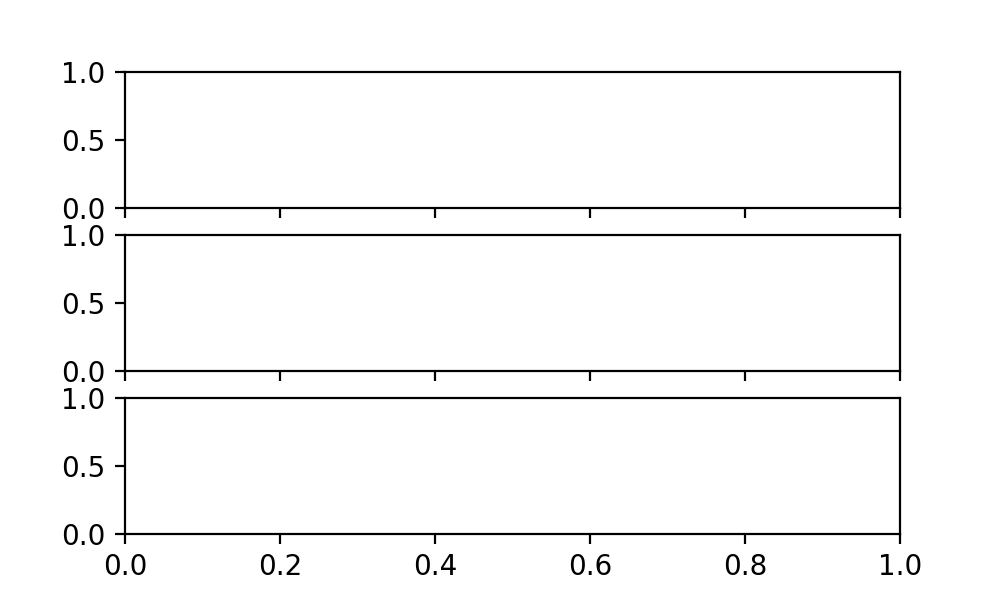

interactive(children=(FloatSlider(value=0.0, description='X rot', max=180.0, min=-180.0, step=1.0), FloatSlide…

<function __main__.update(rx, ry, rz)>

In [47]:
fig, axes = plt.subplots(3,1,sharex=True,figsize=(5,3))
plt.show()

def update(rx, ry, rz):

    R_adjust = R.from_euler("xyz", [rx, ry, rz], degrees=True)

    euler_opti_old = np.vstack([pitch_o, roll_o, yaw_o]).T
    rot_opti_new = R.from_euler("xyz", euler_opti_old, degrees=True)
    rot_corrected = R_adjust * rot_opti_new
    euler_o_new = unwrap_euler(rot_corrected.as_euler("xyz", degrees=True))

    pitch_o_new, roll_o_new, yaw_o_new = euler_o_new.T

    axes[0].cla()
    axes[1].cla()
    axes[2].cla()

    axes[0].plot(time_opti, pitch_o_new, label="Pitch (optitrack)")
    axes[0].plot(time_app, pitch_a, "--", label="Pitch (airpods)")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(time_opti, roll_o_new, label="Roll (optitrack)")
    axes[1].plot(time_app, roll_a, "--", label="Roll (airpods)")
    axes[1].legend()
    axes[1].grid()

    axes[2].plot(time_opti, yaw_o_new, label="Yaw (optitrack)")
    axes[2].plot(time_app, yaw_a, "--", label="Yaw (airpods)")
    axes[2].legend()
    axes[2].grid()

    fig.canvas.draw_idle()

widgets.interact(
    update,
    rx=widgets.FloatSlider(min=-180,max=180,step=1,value=0,description="X rot"),
    ry=widgets.FloatSlider(min=-180,max=180,step=1,value=0,description="Y rot"),
    rz=widgets.FloatSlider(min=-180,max=180,step=1,value=0,description="Z rot"),
)